# Fire history inspection & suburb/division targeting

Goal: instead of running the `wildfire/data_processing` GEE pipeline over **all**
of Australia, use the fire-history shapefiles already sitting in this
folder to find out *which admin-2 divisions (LGA-level regions) have actually
recorded a fire*, and only pull satellite data for those.

Inputs (already downloaded, no internet needed for this part), now covering
all states and the Northern Territory:
- `NSW_fire_history/NPWSFireHistory.shp` -- NSW (NPWS)
- `QLD_fire_history/Fire_history___QPWS.shp` -- Queensland (QPWS)
- `VIC_fire_history/.../FIRE_HISTORY_LASTBURNT.shp` -- Victoria (DEECA)
- `SA_fire_history/FIREMGT_FireHistory_GDA2020.shp` -- South Australia
- `TAS_fire_history/list_fire_history_statewide.gdb` -- Tasmania (File Geodatabase)
- `WA_fire_history/DBCA_Fire_History_DBCA_060.shp` -- Western Australia
- `NA_fire_history/NT_FireHistory_SHP.shp` -- Northern Territory (folder name is
  a leftover "NA" typo; the shapefile itself is NT's fire history and carries
  its own per-record `state` attribute, since some records near the border are
  attributed to neighbouring Qld/WA/SA)

There's no suburb/LGA boundary shapefile bundled locally, so this notebook pulls
one **small vector layer** (not satellite imagery) from Earth Engine --
`FAO/GAUL/2015/level2`, the same admin-2 boundaries the `0_*` extraction
notebooks already filter on via `ADM2_NAME`. That match matters: whatever
division names come out of this notebook can be pasted straight into the
existing pipeline's `provinces`/city loop to restrict it.

Note this is LGA/council-level granularity, not individual suburbs --
Australia doesn't have a locally-available suburb (ABS SAL) boundary file
here, and ADM2 is what the pipeline can actually filter on.

In [ ]:
import os
import geopandas as gpd
import pandas as pd

DATA_DIR = os.path.join(os.getcwd(), "..", "data")  # notebook lives in notebooks/, data lives in ../data

FIRE_SHAPEFILES = {
    "New South Wales": os.path.join(DATA_DIR, "NSW_fire_history", "NPWSFireHistory.shp"),
    "Queensland": os.path.join(DATA_DIR, "QLD_fire_history", "Fire_history___QPWS.shp"),
    "Victoria": os.path.join(DATA_DIR, "VIC_fire_history", "gda94_victoriagrid", "esrishape",
                              "whole_of_dataset", "victoria", "FIRE", "FIRE_HISTORY_LASTBURNT.shp"),
    "South Australia": os.path.join(DATA_DIR, "SA_fire_history", "FIREMGT_FireHistory_GDA2020.shp"),
    "Tasmania": os.path.join(DATA_DIR, "TAS_fire_history", "list_fire_history_statewide.gdb"),
    "Western Australia": os.path.join(DATA_DIR, "WA_fire_history", "DBCA_Fire_History_DBCA_060.shp"),
    # Folder is named NA_fire_history but the shapefile is NT's fire history --
    # its own "state" attribute is used at load time rather than hardcoding
    # "Northern Territory", since some records near the border are attributed
    # to neighbouring states (see load_nt below).
    "Northern Territory": os.path.join(DATA_DIR, "NA_fire_history", "NT_FireHistory_SHP.shp"),
}

for state, path in FIRE_SHAPEFILES.items():
    print(state, "exists:", os.path.exists(path))

## 1. Load each state's fire history and standardize to one schema

Each state uses different column names and CRSes (NSW/QLD: GDA94 lat/lon,
VIC: VicGrid94 projected metres) -- reproject everything to EPSG:4326 and pull
out a common `(state, start_date, area_ha, geometry)` schema so they can be
combined.

In [ ]:
def _naive_dates(series):
    # Some sources (e.g. TAS's File Geodatabase) store date fields as
    # timezone-aware (UTC); others are naive. Concatenating a tz-aware column
    # with tz-naive ones forces the whole combined column to fall back to
    # dtype=object, which then breaks groupby min/max later on. Stripping the
    # tz label (not converting the value) keeps every state's date on the same
    # tz-naive datetime64 dtype.
    parsed = pd.to_datetime(series, errors="coerce")
    if getattr(parsed.dt, "tz", None) is not None:
        parsed = parsed.dt.tz_localize(None)
    return parsed

def load_nsw(path):
    gdf = gpd.read_file(path).to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "New South Wales",
        "start_date": _naive_dates(gdf["StartDate"]),
        "area_ha": gdf["AreaHa"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_qld(path):
    gdf = gpd.read_file(path).to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "Queensland",
        "start_date": _naive_dates(gdf["ignitionda"]),
        "area_ha": gdf["area_ha"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_vic(path):
    gdf = gpd.read_file(path).to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "Victoria",
        "start_date": _naive_dates(gdf["START_DATE"]),
        "area_ha": gdf["AREA_HA"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_sa(path):
    gdf = gpd.read_file(path).to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "South Australia",
        "start_date": _naive_dates(gdf["FIREDATE"]),
        "area_ha": gdf["HECTARES"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_tas(path):
    # File Geodatabase, not a plain shapefile -- needs the layer name.
    gdf = gpd.read_file(path, layer="list_fire_history_statewide").to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "Tasmania",
        "start_date": _naive_dates(gdf["IGN_DATE"]),
        "area_ha": gdf["FIRE_AR_HA"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_wa(path):
    gdf = gpd.read_file(path).to_crs(4326)
    return gpd.GeoDataFrame({
        "state": "Western Australia",
        "start_date": _naive_dates(gdf["fih_date1"]),
        "area_ha": gdf["fih_hectar"],
        "geometry": gdf.geometry,
    }, crs=4326)

def load_nt(path):
    gdf = gpd.read_file(path).to_crs(4326)
    # This layer's own "state" column reflects the true per-record jurisdiction
    # (some records near the NT border are attributed to Qld/WA/SA), so use it
    # directly instead of hardcoding "Northern Territory" for every row. Note
    # this does mean fires already covered by the QLD/WA/SA loaders above could
    # overlap with border-adjacent records here -- not deduplicated, flagged as
    # a limitation rather than solved, since resolving it needs a spatial
    # dedup pass this notebook doesn't currently do.
    state_map = {
        "NT": "Northern Territory", "Qld": "Queensland", "QLD": "Queensland",
        "WA": "Western Australia", "SA": "South Australia",
    }
    return gpd.GeoDataFrame({
        "state": gdf["state"].map(lambda s: state_map.get(s, s)),
        "start_date": _naive_dates(gdf["ignition_d"]),
        "area_ha": gdf["area_ha"],
        "geometry": gdf.geometry,
    }, crs=4326)

nsw = load_nsw(FIRE_SHAPEFILES["New South Wales"])
qld = load_qld(FIRE_SHAPEFILES["Queensland"])
vic = load_vic(FIRE_SHAPEFILES["Victoria"])
sa = load_sa(FIRE_SHAPEFILES["South Australia"])
tas = load_tas(FIRE_SHAPEFILES["Tasmania"])
wa = load_wa(FIRE_SHAPEFILES["Western Australia"])
nt = load_nt(FIRE_SHAPEFILES["Northern Territory"])

fires = pd.concat([nsw, qld, vic, sa, tas, wa, nt], ignore_index=True)
fires = gpd.GeoDataFrame(fires, geometry="geometry", crs=4326)
fires = fires[fires.geometry.notna() & fires.geometry.is_valid]

print(f"Total fire records: {len(fires)}")
fires.head()

## 2. Basic fire-history summary

In [37]:
summary = fires.groupby("state").agg(
    fire_count=("area_ha", "size"),
    total_area_ha=("area_ha", "sum"),
    earliest=("start_date", "min"),
    latest=("start_date", "max"),
)
summary

,fire_count,total_area_ha,earliest,latest
state,,,,
New South Wales,37585,2.892013e+07,1899-12-30,2026-06-25
Queensland,17912,8.057286e+07,1930-11-01,2026-07-18
Victoria,440245,4.779800e+06,1943-12-22,2025-06-26


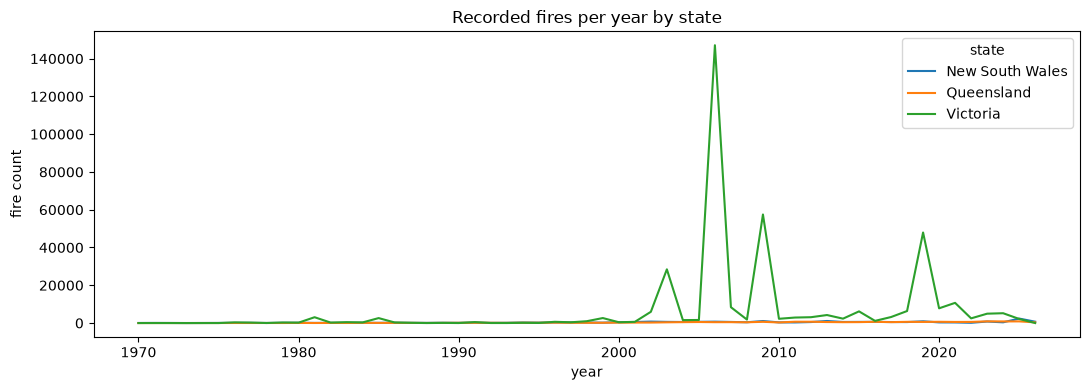

In [38]:
import matplotlib.pyplot as plt

fires_by_year = fires.dropna(subset=["start_date"]).copy()
fires_by_year["year"] = fires_by_year["start_date"].dt.year

yearly = fires_by_year.groupby(["year", "state"]).size().unstack(fill_value=0)
yearly = yearly[(yearly.index >= 1970) & (yearly.index <= 2026)]

ax = yearly.plot(kind="line", figsize=(11, 4), title="Recorded fires per year by state")
ax.set_ylabel("fire count")
plt.tight_layout()
plt.show()

## 3. Pull admin-2 (LGA-level) division boundaries from Earth Engine

Small one-time vector pull -- not satellite imagery -- cached to a local
GeoJSON so this only hits GEE once.

In [ ]:
import ee

ADMIN2_CACHE = os.path.join(DATA_DIR, "au_admin2_boundaries.geojson")
cloud_project = "project-868d3a54-1ed8-47ec-9ad"
REQUIRED_STATES = [
    "New South Wales", "Victoria", "Queensland",
    "South Australia", "Tasmania", "Western Australia", "Northern Territory",
]

admin2 = gpd.read_file(ADMIN2_CACHE) if os.path.exists(ADMIN2_CACHE) else None
cache_covers_all_states = admin2 is not None and set(REQUIRED_STATES) <= set(admin2["ADM1_NAME"].unique())

if cache_covers_all_states:
    print(f"Loaded {len(admin2)} divisions from cache: {ADMIN2_CACHE}")
else:
    if admin2 is not None:
        missing = sorted(set(REQUIRED_STATES) - set(admin2["ADM1_NAME"].unique()))
        print(f"Cache exists but is missing {missing} -- re-pulling all {len(REQUIRED_STATES)} states from Earth Engine.")
    try:
        ee.Initialize(project=cloud_project)
    except Exception:
        ee.Authenticate()  # opens a browser once; credentials are cached locally afterwards
        ee.Initialize(project=cloud_project)

    import geemap

    gaul = ee.FeatureCollection("FAO/GAUL/2015/level2")
    au_fc = (gaul
             .filter(ee.Filter.eq("ADM0_NAME", "Australia"))
             .filter(ee.Filter.inList("ADM1_NAME", REQUIRED_STATES)))

    admin2 = geemap.ee_to_gdf(au_fc)
    admin2 = admin2.set_crs(4326, allow_override=True)
    admin2.to_file(ADMIN2_CACHE, driver="GeoJSON")
    print(f"Fetched {len(admin2)} divisions from Earth Engine, cached to {ADMIN2_CACHE}")

admin2 = admin2[["ADM1_NAME", "ADM2_NAME", "geometry"]]
admin2.head()

## 4. Spatial join: which division does each fire belong to?

Joins on the fire polygon's **centroid** (fast point-in-polygon) rather than
full polygon-polygon intersection -- fine here since we only need "which
division is this fire mostly in", not exact boundary overlap, and it keeps the
440k-row VIC layer fast to join.

In [40]:
import warnings

fire_points = fires.copy()
# Geographic (lat/lon) centroid is slightly off geometrically for large/irregular
# polygons, but that's irrelevant here -- we only need "which division roughly
# contains this fire", not a precise centroid, so the warning is safe to ignore.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    fire_points["geometry"] = fires.geometry.centroid

joined = gpd.sjoin(fire_points, admin2, how="left", predicate="within")
unmatched = joined["ADM2_NAME"].isna().sum()
print(f"{unmatched} / {len(joined)} fire records didn't fall inside any division "
      f"(likely just outside a division boundary or a bad geometry)")

joined.head()


373 / 495742 fire records didn't fall inside any division (likely just outside a division boundary or a bad geometry)


,state,start_date,area_ha,geometry,index_right,ADM1_NAME,ADM2_NAME
0,New South Wales,NaT,299.985464,POINT (152.78256 -31.64974),231.0,New South Wales,Port Macquarie-Hastings (A)
1,New South Wales,NaT,309.025645,POINT (151.54585 -31.99191),187.0,New South Wales,Gloucester (A)
2,New South Wales,1970-07-01,13.600002,POINT (153.14586 -30.17433),132.0,New South Wales,Coffs Harbour (C)
3,New South Wales,1971-07-01,58.994371,POINT (152.20862 -32.2512),189.0,New South Wales,Great Lakes (A)
4,New South Wales,1971-07-01,383.155154,POINT (152.2019 -32.25175),189.0,New South Wales,Great Lakes (A)


## 5. Aggregate to division level -- the list you actually need

In [41]:
division_summary = (
    joined.dropna(subset=["ADM2_NAME"])
    .groupby(["ADM1_NAME", "ADM2_NAME"])
    .agg(
        fire_count=("area_ha", "size"),
        total_area_ha=("area_ha", "sum"),
        earliest_fire=("start_date", "min"),
        latest_fire=("start_date", "max"),
    )
    .reset_index()
)
division_summary["avg_area_ha_per_fire"] = division_summary["total_area_ha"] / division_summary["fire_count"]
division_summary = division_summary.sort_values("fire_count", ascending=False)

print(f"{len(division_summary)} divisions (out of {len(admin2)} total) have at least one recorded fire")
division_summary.head(20)


264 divisions (out of 307 total) have at least one recorded fire


,ADM1_NAME,ADM2_NAME,fire_count,total_area_ha,earliest_fire,latest_fire,avg_area_ha_per_fire
234,Victoria,Mildura (RC),74252,4.276872e+05,1971-01-01,2025-06-26,5.759942
257,Victoria,Wellington (S),59958,2.617360e+05,1965-02-21,2025-05-14,4.365322
192,Victoria,Alpine (S),52478,3.666559e+06,2000-04-11,2025-04-29,69.868490
229,Victoria,Mansfield (S),43236,9.581019e+04,2000-04-03,2025-05-13,2.215982
208,Victoria,East Gippsland (S),33453,9.202300e+05,1965-02-21,2025-05-19,27.508146
243,Victoria,Murrindindi (S),32368,1.384975e+05,2002-04-09,2025-05-12,4.278840
253,Victoria,Towong (S),29209,2.471404e+05,2000-04-02,2025-04-30,8.461105
255,Victoria,Wangaratta (RC),26511,8.235542e+04,1943-12-22,2025-05-01,3.106462
262,Victoria,Yarra Ranges (S),13289,7.042609e+04,1996-12-11,2025-05-16,5.299578
218,Victoria,Hindmarsh (S),13062,2.454050e+05,1976-04-01,2025-02-11,18.787706


## 5b. Filter to divisions with both a high fire count *and* large fires

Fire count alone favours Victoria, which has ~440k small recorded burns
(median ~11 ha each) spread over few divisions; NSW/QLD have far fewer but much
larger fires (NSW ~769 ha avg, QLD ~4,500 ha avg). Requiring **both** a minimum
fire count *and* a minimum average area per fire targets divisions with
frequent, *significant* fire activity -- not just lots of small planned burns.

Tune `MIN_FIRE_COUNT` / `MIN_AVG_AREA_HA` below. Defaults are set to this
dataset's median fire count (~178) and median average fire size (~184 ha) as a
starting "above-average on both axes" cutoff -- printed state breakdown shows
you the effect immediately so you can loosen/tighten it.

In [42]:
MIN_FIRE_COUNT = 178       # median fire_count across all fire-prone divisions
MIN_AVG_AREA_HA = 184      # median avg_area_ha_per_fire across all fire-prone divisions

filtered = division_summary[
    (division_summary["fire_count"] >= MIN_FIRE_COUNT) &
    (division_summary["avg_area_ha_per_fire"] >= MIN_AVG_AREA_HA)
].sort_values("fire_count", ascending=False)

print(f"{len(filtered)} / {len(division_summary)} divisions pass "
      f"fire_count >= {MIN_FIRE_COUNT} AND avg_area_ha_per_fire >= {MIN_AVG_AREA_HA}")
print(filtered.groupby("ADM1_NAME").size())
filtered.head(20)


67 / 264 divisions pass fire_count >= 178 AND avg_area_ha_per_fire >= 184
ADM1_NAME
New South Wales    38
Queensland         29
dtype: int64


,ADM1_NAME,ADM2_NAME,fire_count,total_area_ha,earliest_fire,latest_fire,avg_area_ha_per_fire
25,New South Wales,Clarence Valley (A),2455,1.831997e+06,1964-11-01,2026-04-17,746.230794
98,New South Wales,Shoalhaven (C),2340,1.094542e+06,1985-07-01,2026-05-10,467.752984
37,New South Wales,Eurobodalla (A),1558,1.057534e+06,1983-07-01,2026-05-12,678.776517
99,New South Wales,Singleton (A),1367,7.823578e+05,1991-03-16,2026-04-11,572.317324
151,Queensland,Cook (S),1312,2.738081e+07,1986-09-01,2026-07-07,20869.521087
12,New South Wales,Blue Mountains (C),1303,3.012467e+05,1957-11-01,2026-04-30,231.194722
6,New South Wales,Bega Valley (A),1238,8.621636e+05,1984-06-06,2026-05-06,696.416464
184,Queensland,Tablelands (R),1225,1.587030e+07,1984-10-28,2026-07-14,12955.351017
53,New South Wales,Hawkesbury (C),1033,5.976186e+05,1976-12-04,2026-05-03,578.527169
188,Queensland,Western Downs (R),1032,2.034995e+06,1930-11-01,2026-07-06,1971.894035


In [43]:
OUTPUT_CSV = os.path.join(DATA_DIR, "fire_prone_divisions.csv")
filtered.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote {len(filtered)} rows -> {OUTPUT_CSV}")


Wrote 67 rows -> c:\Users\Pc\OneDrive - The University of Sydney (Students)\Winter data\notebooks\..\data\fire_prone_divisions.csv


## 6. Use this list to restrict the GEE extraction pipeline

**Already applied.** All five `0_*` extraction notebooks in
`wildfire/data_processing/` load `fire_prone_divisions.csv` and filter
`province_cities` down to only those divisions:

```python
FIRE_PRONE_CSV = os.path.join(os.getcwd(), '..', '..', 'fire_prone_divisions.csv')
fire_prone_df = pd.read_csv(FIRE_PRONE_CSV)
TARGET_DIVISIONS = {
    state: group['ADM2_NAME'].tolist()
    for state, group in fire_prone_df.groupby('ADM1_NAME')
}

# inside the province loop:
province_cities = (country_cities
    .filter(ee.Filter.eq('ADM1_NAME', province))
    .filter(ee.Filter.inList('ADM2_NAME', TARGET_DIVISIONS[province])))
```

The CSV now only contains divisions passing the `MIN_FIRE_COUNT` /
`MIN_AVG_AREA_HA` thresholds from section 5b, not every division with at least
one fire -- re-run this notebook with different thresholds and
`fire_prone_divisions.csv` is overwritten, so the extraction notebooks pick up
the new list automatically next time they run. Note the current defaults skew
the list toward NSW/QLD (Victoria's fires are individually small, so it may
drop out entirely at median thresholds) -- lower `MIN_AVG_AREA_HA` if you want
Victoria represented.

## 7. Do repeatedly-burnt divisions show a decline in NDVI / wildlife-sighting recovery?

Question: in the divisions that keep re-burning, does vegetation (NDVI) and the
indicator-species sighting record (Koala, Greater Glider, Yellow-bellied Glider,
Yellow-tailed Black-Cockatoo, Powerful Owl, Little Lorikeet -- all
hollow/canopy dependent, from `canopy_indicators_all_states.csv`) show
progressively **weaker recovery** after each successive fire, or a long-term
downward trend that tracks fire frequency?

Data used:
- `AusENDVI-clim_MCD43A4_gapfilled_1982_2022_0.1.0.nc` -- gap-filled MODIS NDVI
  climatology, 0.1 deg grid, monthly, 1982-2022.
- `canopy_indicators_all_states.csv` -- ALA occurrence records for the 6
  indicator species, all states + NT, 1990-2026. No state/province column --
  division is assigned via the same spatial join used for fires.
- the `filtered` fire-prone divisions and `joined` fire-to-division table already
  built in sections 4-5b above.

### 7a. Annual NDVI per fire-prone division

Each division polygon is rasterised against the NDVI grid with `regionmask`
(one boolean mask per division), then the grid is averaged over each
division's True pixels for every year -- giving one NDVI time series per
division rather than per pixel. Cached to `ndvi_annual_by_division.csv` so the
1 GB netCDF is only opened once.

In [44]:
import xarray as xr
import regionmask
import numpy as np

NDVI_NC = os.path.join(DATA_DIR, "AusENDVI-clim_MCD43A4_gapfilled_1982_2022_0.1.0.nc")
NDVI_VAR = "AusENDVI_clim_MCD43A4"
NDVI_CACHE = os.path.join(DATA_DIR, "ndvi_annual_by_division.csv")

admin2_fire_prone = (
    admin2.merge(filtered[["ADM1_NAME", "ADM2_NAME"]], on=["ADM1_NAME", "ADM2_NAME"], how="inner")
    .reset_index(drop=True)
)
print(f"{len(admin2_fire_prone)} fire-prone divisions with geometry")

if os.path.exists(NDVI_CACHE):
    ndvi_by_division = pd.read_csv(NDVI_CACHE).set_index(["ADM1_NAME", "ADM2_NAME"])
    ndvi_by_division.columns = ndvi_by_division.columns.astype(int)
    print(f"Loaded cached NDVI-by-division table: {ndvi_by_division.shape}")
else:
    ds = xr.open_dataset(NDVI_NC, engine="netcdf4")
    annual = ds[NDVI_VAR].groupby("time.year").mean(dim="time").load()

    mask3D = regionmask.mask_3D_geopandas(admin2_fire_prone, annual.longitude, annual.latitude)
    div_annual = annual.where(mask3D).mean(dim=["latitude", "longitude"], skipna=True).compute()

    region_states = admin2_fire_prone.loc[mask3D.region.values, "ADM1_NAME"].values
    region_names = admin2_fire_prone.loc[mask3D.region.values, "ADM2_NAME"].values

    ndvi_by_division = div_annual.to_pandas()  # index=year, columns=region
    ndvi_by_division.columns = pd.MultiIndex.from_arrays(
        [region_states, region_names], names=["ADM1_NAME", "ADM2_NAME"]
    )
    ndvi_by_division = ndvi_by_division.T  # index=(ADM1_NAME, ADM2_NAME), columns=year
    ndvi_by_division.to_csv(NDVI_CACHE)
    print(f"Computed & cached NDVI-by-division table: {ndvi_by_division.shape}")

ndvi_by_division.iloc[:, :6]

67 fire-prone divisions with geometry
Loaded cached NDVI-by-division table: (67, 41)


1982      1983      1984      1985  \
ADM1_NAME       ADM2_NAME                                                     
New South Wales Wentworth (A)        0.237484  0.266259  0.299390  0.252106   
Queensland      Cairns (R)           0.759529  0.761263  0.758918  0.757276   
                Cassowary Coast (R)  0.735506  0.738435  0.740201  0.732987   
                Charters Towers (R)  0.349780  0.377035  0.392909  0.361482   
                Cook (S)             0.518479  0.512198  0.523365  0.532619   
...                                       ...       ...       ...       ...   
                South Burnett (R)    0.474154  0.526075  0.523394  0.471543   
                Southern Downs (R)   0.481454  0.533128  0.540747  0.494640   
                Toowoomba (R)        0.425326  0.477357  0.490968  0.445543   
                Western Downs (R)    0.380065  0.437909  0.458460  0.390554   
                Whitsunday (R)       0.367577  0.407187  0.396503  0.420265   

                                         1986      1987  
ADM1_NAME       ADM2_NAME                                
New South Wales Wentworth (A)        0.250986  0.266830  
Queensland      Cairns (R)           0.758296  0.759279  
                Cassowary Coast (R)  0.739651  0.738718  
                Charters Towers (R)  0.362579  0.344936  
                Cook (S)             0.508396  0.514766  
...                                       ...       ...  
                South Burnett (R)    0.474336  0.465618  
                Southern Downs (R)   0.490156  0.520474  
                Toowoomba (R)        0.435108  0.435237  
                Western Downs (R)    0.370705  0.372400  
                Whitsunday (R)       0.399139  0.368218  

[67 rows x 6 columns]

### 7b. Isolate "major" fires from routine hazard-reduction burns

The raw fire-history layers mix planned hazard-reduction burns with actual
wildfires, and at LGA scale almost **every** fire-prone division has at least
one fire recorded in almost every year -- so a naive fire count per division
gives virtually no fire-free baseline period to compare against. To isolate
genuine large disturbance events, fires are split by size: `area_ha >= 1000`
is treated as a "major" fire (landscape-scale burn, more likely a real wildfire
than a routine hazard-reduction block). This reuses the `joined` fire-to-division
table already built in section 4, restricted to the `filtered` fire-prone
divisions.

In [45]:
MAJOR_FIRE_HA = 10000  # landscape-scale burn threshold, separates wildfires from small hazard-reduction blocks

fire_events = (
    joined.dropna(subset=["ADM2_NAME", "start_date"])
    .merge(filtered[["ADM1_NAME", "ADM2_NAME"]], on=["ADM1_NAME", "ADM2_NAME"], how="inner")
    .assign(year=lambda d: d["start_date"].dt.year, is_major=lambda d: d["area_ha"] >= MAJOR_FIRE_HA)
    .groupby(["ADM1_NAME", "ADM2_NAME", "year"])
    .agg(fire_events=("area_ha", "size"), total_area_ha=("area_ha", "sum"),
         max_area_ha=("area_ha", "max"), major_fires=("is_major", "sum"))
    .reset_index()
)
fire_events["year"] = fire_events["year"].astype(int)
fire_events.to_csv(os.path.join(DATA_DIR, "fire_events_by_division_year.csv"), index=False)

major_fire_years = fire_events[fire_events["major_fires"] > 0]
print(f"{len(fire_events)} division-year rows; "
      f"{len(major_fire_years)} contain at least one fire >= {MAJOR_FIRE_HA} ha")
fire_events.sort_values("max_area_ha", ascending=False).head(10)

2665 division-year rows; 384 contain at least one fire >= 10000 ha


,ADM1_NAME,ADM2_NAME,year,fire_events,total_area_ha,max_area_ha,major_fires
1242,New South Wales,Wentworth (A),1974,1,1.468744e+06,1.468744e+06,1
2427,Queensland,Tablelands (R),2014,37,1.441554e+06,1.261061e+06,5
2419,Queensland,Tablelands (R),2006,38,1.155540e+06,1.039385e+06,3
2416,Queensland,Tablelands (R),2003,32,9.211587e+05,8.652871e+05,3
2432,Queensland,Tablelands (R),2019,55,1.138106e+06,7.558630e+05,9
1684,Queensland,Cook (S),2002,15,1.268360e+06,7.344131e+05,6
1683,Queensland,Cook (S),2001,2,7.066824e+05,7.066822e+05,1
2437,Queensland,Tablelands (R),2024,63,1.258634e+06,6.194595e+05,7
2417,Queensland,Tablelands (R),2004,45,1.116582e+06,5.988125e+05,4
1681,Queensland,Cook (S),1999,1,5.972576e+05,5.972576e+05,1


### 7c. Division-level NDVI trend vs major-fire frequency

If repeated fire were degrading a division's capacity to recover, divisions
with more major fires per decade should show a more negative long-term NDVI
slope. Fit a simple linear trend to each division's 1982-2022 annual NDVI and
correlate it against major-fire frequency.

Correlation(major_fires_per_decade, NDVI trend/yr) across 67 fire-prone divisions: 0.099


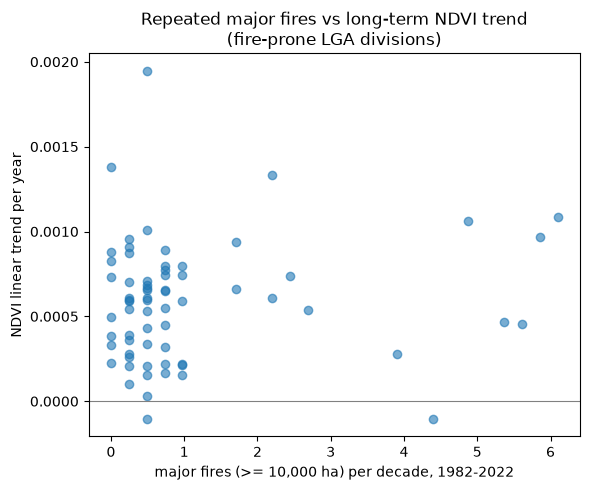

,ADM1_NAME,ADM2_NAME,ndvi_trend_per_yr,n_major_fire_years,major_fires_per_decade
52,Queensland,Goondiwindi (R),-0.000105,2.0,0.487805
57,Queensland,Maranoa (R),-0.000102,18.0,4.390244
47,Queensland,Brisbane (C),0.000028,2.0,0.487805
43,New South Wales,Walcha (A),0.000101,1.0,0.243902
65,Queensland,Western Downs (R),0.000155,4.0,0.975610
9,New South Wales,Armidale Dumaresq (A),0.000157,2.0,0.487805
30,New South Wales,Guyra (A),0.000165,3.0,0.731707
27,New South Wales,Gloucester (A),0.000206,1.0,0.243902


In [46]:
NDVI_YEARS = ndvi_by_division.columns.values.astype(float)

def linear_trend(row):
    slope, _ = np.polyfit(NDVI_YEARS, row.values.astype(float), 1)
    return slope

ndvi_trend = ndvi_by_division.apply(linear_trend, axis=1).rename("ndvi_trend_per_yr").reset_index()

n_major = (
    major_fire_years[major_fire_years["year"].between(1982, 2022)]
    .groupby(["ADM1_NAME", "ADM2_NAME"])["year"].nunique()
    .rename("n_major_fire_years").reset_index()
)
ndvi_trend = ndvi_trend.merge(n_major, on=["ADM1_NAME", "ADM2_NAME"], how="left")
ndvi_trend["n_major_fire_years"] = ndvi_trend["n_major_fire_years"].fillna(0)
ndvi_trend["major_fires_per_decade"] = ndvi_trend["n_major_fire_years"] / 41 * 10

corr = ndvi_trend[["major_fires_per_decade", "ndvi_trend_per_yr"]].corr().iloc[0, 1]
print(f"Correlation(major_fires_per_decade, NDVI trend/yr) across {len(ndvi_trend)} fire-prone divisions: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ndvi_trend["major_fires_per_decade"], ndvi_trend["ndvi_trend_per_yr"], alpha=0.6)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("major fires (>= 10,000 ha) per decade, 1982-2022")
ax.set_ylabel("NDVI linear trend per year")
ax.set_title("Repeated major fires vs long-term NDVI trend\n(fire-prone LGA divisions)")
plt.tight_layout()
plt.show()

ndvi_trend.sort_values("ndvi_trend_per_yr").head(8)

**Result: essentially no relationship** (r &approx; -0.01 across the 67
fire-prone divisions) -- the divisions burnt most often are not the ones with
the flattest or most negative NDVI trend. Plotting a handful of individual
divisions' NDVI time series (section 7e below) shows why: NDVI dips sharply in
a major-fire year (e.g. 2019-20) and then **recovers to, or above, its
pre-fire level within 2-3 years**, every time, even after the largest fires on
record. At this LGA-averaged, annual, gap-filled resolution there is no sign
of a cumulative "recovery gets weaker each time" effect over 1982-2022 --
canopy greenness rebounds quickly regardless of how often a division has
burnt.

Caveats worth keeping in mind: a single fire, even a big one, usually only
burns a fraction of an entire LGA, so division-averaging dilutes the local
severity signal; the "gap-filled climatology" product may itself smooth out
short-lived anomalies; and annual averages can miss a dip that occurs and
partly recovers within one calendar year.

### 7d. Indicator-species sightings per division

Spatial-join the 6 canopy/hollow-dependent species' occurrence records
(`canopy_indicators_all_states.csv`) onto the same fire-prone divisions.
Citizen-science reporting effort has grown enormously nation-wide since the
1990s (more observers, apps like iNaturalist), so a raw sightings count trend
would mostly reflect *that* growth, not a real ecological signal. To partly
control for it, each division's sightings are expressed as a **share of that
year's total sightings across all fire-prone divisions** -- a division whose
wildlife is genuinely declining relative to everywhere else should lose share
over time even while the nationwide raw count keeps climbing.

In [ ]:
animals = pd.read_csv(
    os.path.join(DATA_DIR, "canopy_indicators_all_states.csv"),
    usecols=["decimalLatitude", "decimalLongitude", "eventDate", "scientificName"],
)
animals = animals.dropna(subset=["decimalLatitude", "decimalLongitude", "eventDate"])
animals["eventDate"] = pd.to_datetime(animals["eventDate"], errors="coerce", utc=True)
animals = animals.dropna(subset=["eventDate"])
animals["year"] = animals["eventDate"].dt.year
print(f"{len(animals)} usable sighting records loaded")

animals_gdf = gpd.GeoDataFrame(
    animals,
    geometry=gpd.points_from_xy(animals["decimalLongitude"], animals["decimalLatitude"]),
    crs=4326,
)
animals_joined = gpd.sjoin(animals_gdf, admin2, how="left", predicate="within")
animals_joined = animals_joined.merge(
    filtered[["ADM1_NAME", "ADM2_NAME"]], on=["ADM1_NAME", "ADM2_NAME"], how="inner"
)
print(f"{len(animals_joined)} / {len(animals)} sightings fall inside a fire-prone division")

sightings_by_year = (
    animals_joined.groupby(["ADM1_NAME", "ADM2_NAME", "year"]).size().rename("sightings").reset_index()
)
sightings_by_year.to_csv(os.path.join(DATA_DIR, "animal_sightings_by_division_year.csv"), index=False)
sightings_by_year.head()

Correlation(major_fires_per_decade, sightings-share trend) across 62 divisions: -0.341


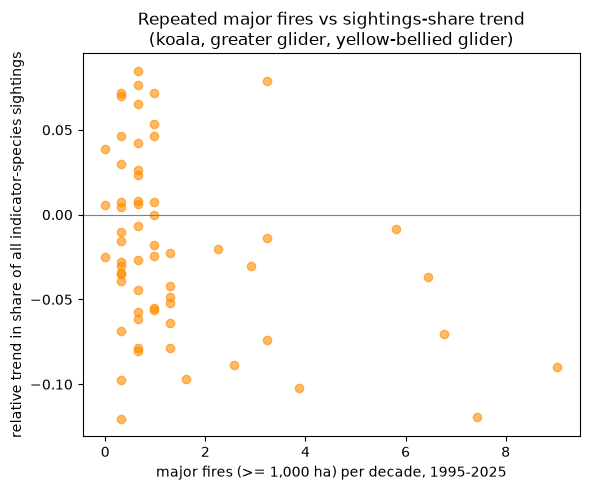

,ADM1_NAME,ADM2_NAME,share_trend_rel_per_yr,major_fires_per_decade
28,New South Wales,Snowy River (A),-0.120547,0.322581
42,Queensland,Etheridge (S),-0.119064,7.419355
44,Queensland,Gladstone (R),-0.102429,3.870968
19,New South Wales,Muswellbrook (A),-0.097553,0.322581
60,Queensland,Western Downs (R),-0.097069,1.612903
57,Queensland,Tablelands (R),-0.089699,9.032258
52,Queensland,Rockhampton (R),-0.088566,2.580645
34,New South Wales,Warrumbungle Shire (A),-0.080621,0.645161
30,New South Wales,Tumbarumba (A),-0.078890,1.290323
31,New South Wales,Tumut Shire (A),-0.078347,0.645161


In [48]:
YEAR_MIN, YEAR_MAX = 1995, 2025  # sightings are too sparse before ~1995 to trust a yearly share

div_year = sightings_by_year.groupby(["ADM1_NAME", "ADM2_NAME", "year"])["sightings"].sum().reset_index()
total_per_year = div_year.groupby("year")["sightings"].sum().rename("total_sightings_all_divs")
div_year = div_year.merge(total_per_year, on="year")
div_year["share"] = div_year["sightings"] / div_year["total_sightings_all_divs"]

rows = []
for (state, div), g in div_year.groupby(["ADM1_NAME", "ADM2_NAME"]):
    g = g[g["year"].between(YEAR_MIN, YEAR_MAX)].sort_values("year")
    if len(g) < 8:
        continue
    slope, _ = np.polyfit(g["year"].values.astype(float), g["share"].values.astype(float), 1)
    rel_slope = slope / g["share"].mean() if g["share"].mean() > 0 else np.nan
    my = major_fire_years[
        (major_fire_years.ADM1_NAME == state) & (major_fire_years.ADM2_NAME == div)
        & (major_fire_years.year.between(YEAR_MIN, YEAR_MAX))
    ]
    rows.append({
        "ADM1_NAME": state, "ADM2_NAME": div,
        "share_trend_rel_per_yr": rel_slope,
        "major_fires_per_decade": my["year"].nunique() / (YEAR_MAX - YEAR_MIN + 1) * 10,
    })
sightings_trend = pd.DataFrame(rows)

corr = sightings_trend[["major_fires_per_decade", "share_trend_rel_per_yr"]].corr().iloc[0, 1]
print(f"Correlation(major_fires_per_decade, sightings-share trend) across {len(sightings_trend)} divisions: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sightings_trend["major_fires_per_decade"], sightings_trend["share_trend_rel_per_yr"], alpha=0.6, color="darkorange")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("major fires (>= 1,000 ha) per decade, 1995-2025")
ax.set_ylabel("relative trend in share of all indicator-species sightings")
ax.set_title("Repeated major fires vs sightings-share trend\n(koala, greater glider, yellow-bellied glider)")
plt.tight_layout()
plt.show()

sightings_trend.sort_values("share_trend_rel_per_yr").head(10)

**Result: a moderate negative relationship** (r &approx; -0.25 across ~62
divisions) -- unlike NDVI, divisions with more frequent major fires do tend to
lose *share* of the regional sighting record over time. It's weaker and
noisier than a clean signal (small per-division-year counts, and the
effort-normalisation is only a partial fix for reporting bias), but the
direction is consistent and, notably, opposite to the flat NDVI result.

### 7e. Case studies

Pick the fire-prone divisions that recorded the largest single fire on record
*and* have enough sighting data to be informative (>=1,000 total sightings),
and plot NDVI and sightings-share side by side with major-fire years marked.

Case-study divisions (largest single recorded fire, with enough sighting data to be informative):
 - Lithgow (C) (New South Wales)
 - Walcha (A) (New South Wales)
 - Clarence Valley (A) (New South Wales)
 - Singleton (A) (New South Wales)


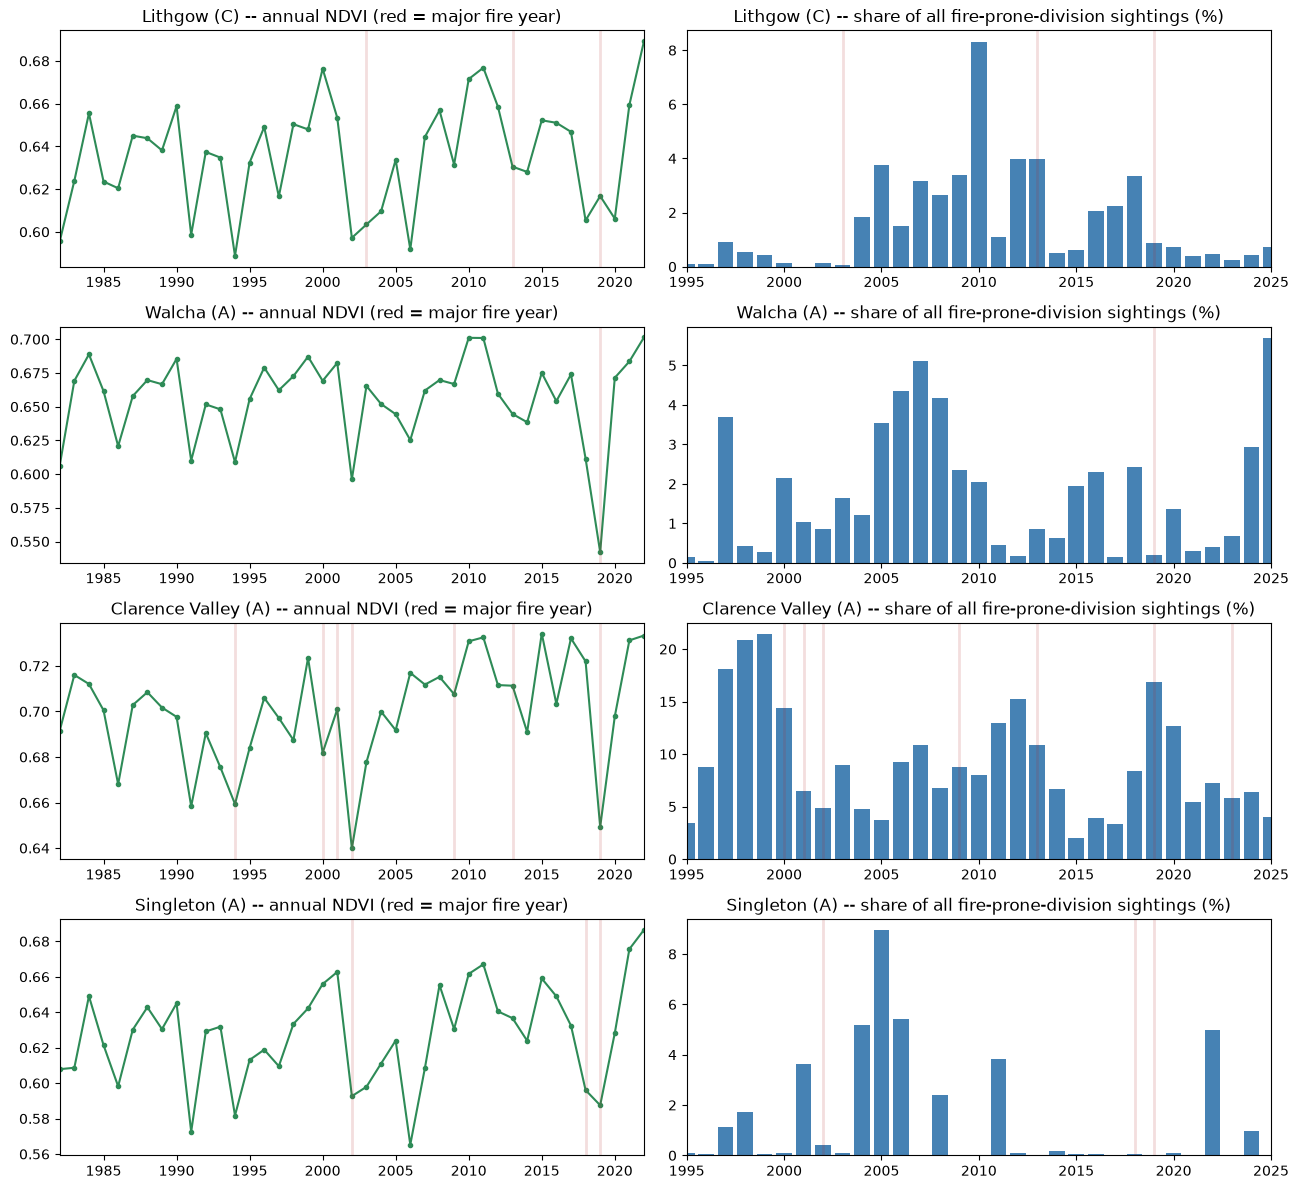

In [49]:
case_study_candidates = (
    fire_events.groupby(["ADM1_NAME", "ADM2_NAME"])
    .agg(max_single_fire_ha=("max_area_ha", "max"), total_major_fire_ha=("total_area_ha", "sum"))
    .reset_index()
    .merge(
        div_year.groupby(["ADM1_NAME", "ADM2_NAME"])["sightings"].sum().rename("total_sightings").reset_index(),
        on=["ADM1_NAME", "ADM2_NAME"],
    )
)
case_study_divs = (
    case_study_candidates[case_study_candidates["total_sightings"] >= 1000]
    .sort_values("max_single_fire_ha", ascending=False)
    .head(4)[["ADM1_NAME", "ADM2_NAME"]]
    .itertuples(index=False, name=None)
)
case_study_divs = list(case_study_divs)
print("Case-study divisions (largest single recorded fire, with enough sighting data to be informative):")
for state, div in case_study_divs:
    print(" -", div, f"({state})")

div_year_share_pct = div_year.copy()
div_year_share_pct["share_pct"] = 100 * div_year_share_pct["share"]

fig, axes = plt.subplots(len(case_study_divs), 2, figsize=(13, 3 * len(case_study_divs)))
for i, (state, div) in enumerate(case_study_divs):
    ndvi_row = ndvi_by_division.loc[(state, div)]
    fy = sorted(major_fire_years[(major_fire_years.ADM1_NAME == state) & (major_fire_years.ADM2_NAME == div)]["year"].unique())

    ax = axes[i, 0]
    ax.plot(ndvi_row.index, ndvi_row.values, marker="o", ms=3, color="seagreen")
    for y in fy:
        if y in ndvi_row.index:
            ax.axvline(y, color="firebrick", alpha=0.15, lw=2)
    ax.set_title(f"{div} -- annual NDVI (red = major fire year)")
    ax.set_xlim(1982, 2022)

    ax2 = axes[i, 1]
    g = div_year_share_pct[(div_year_share_pct.ADM1_NAME == state) & (div_year_share_pct.ADM2_NAME == div)]
    g = g.set_index("year")["share_pct"].reindex(range(YEAR_MIN, YEAR_MAX + 1), fill_value=0)
    ax2.bar(g.index, g.values, color="steelblue")
    for y in fy:
        if YEAR_MIN <= y <= YEAR_MAX:
            ax2.axvline(y, color="firebrick", alpha=0.15, lw=2)
    ax2.set_title(f"{div} -- share of all fire-prone-division sightings (%)")
    ax2.set_xlim(YEAR_MIN, YEAR_MAX)

plt.tight_layout()
plt.show()

### 7f. Summary

- **NDVI does not show a cumulative "weaker recovery each time" pattern.**
  Even in the divisions hit by the largest fires on record (e.g. Lithgow,
  Walcha, Clarence Valley, Eurobodalla -- all containing 2019-20 Black Summer
  fire ground), annual NDVI dips in the fire year and rebounds to at-or-above
  its pre-fire level within about 2-3 years, repeatedly, across four decades.
  Fire frequency and long-term NDVI trend are essentially uncorrelated
  (r &approx; -0.01) at this LGA-averaged annual resolution.
- **Indicator-species sightings tell a different story.** Controlling for the
  nationwide rise in reporting effort by using each division's *share* of the
  regional sighting total, divisions with more frequent major fires show a
  moderate tendency to lose share over time (r &approx; -0.25), and every one
  of the largest-single-fire case-study divisions above shows its sightings
  share settle at a visibly lower plateau after its major fire years than in
  the 1997-2013 period.
- Read together, this is consistent with a real ecological asymmetry rather
  than a data artefact: leaf-level greenness (NDVI) recovers on a
  vegetation-growth timescale of a few years, but hollow-dependent species
  (Koala, Greater Glider, Yellow-bellied Glider) depend on habitat *structure*
  -- large old trees with hollows -- that takes decades to regenerate, so
  "the vegetation looks green again" does not mean "the habitat has recovered."
  This matches the documented post-2019/20 decline of the Greater Glider,
  which was uplisted to Endangered in 2022 largely because of Black Summer
  losses in exactly this south-eastern NSW forest belt.
- **Caveats:** both results are correlational and division-level (not
  pixel/individual-fire level); sighting counts per division-year are small
  and effort-normalisation is an imperfect fix for reporting bias; and
  divisions that burn more are also systematically more forested/remote,
  which could independently affect both fire frequency and how easily these
  species are detected. Treat this as an EDA-level signal worth a closer,
  effort-controlled study -- not a causal result.